In [2]:
from py_files.setup import *
setup_notebook()

# `Solving`the dynamic problem

**Intention:** I build a class, that performs the necessary steps to replicate `Figure 5`in the paper. 

**Outcome:** Get a better grasp on the model dynamics and replicate their results - then only DK-calibration/extention is left.

### 1. `Main simulation`

In [3]:
# m = CapIncModel_single()
m = CapIncModel()
out = m.calibrate()


 Calibrate household: zero wage premia + target eps_nI 
targets    prem1=0, prem2=0, eps1=1.0, eps2=0.3
------------------------------------------------------------
old        mu1=0.26, mu2=0.25   =>
           log(w1I/w1C)=-1.12e-01, log(w2I/w2C)=-9.56e-03

old        phi1=1.00, phi2=0.30 =>
           eps1=0.761, eps2=0.225
------------------------------------------------------------
new        mu1=0.2192, mu2=0.2477   =>
           log(w1I/w1C)=-3.25e-12, log(w2I/w2C)=+5.39e-11

new        phi1=1.2807, phi2=0.3988 =>
           eps1=1.000, eps2=0.300



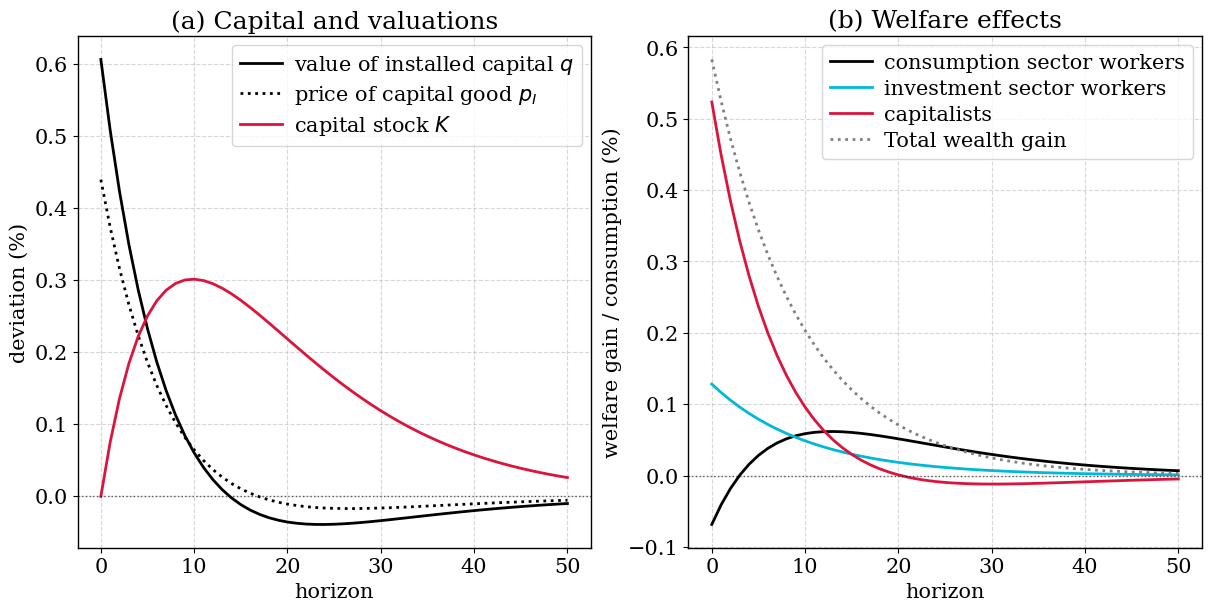

In [4]:
# 1. link to molde
ss0 = m.solve_steady_state(tau=0.0)

# 2. get tau path
net_long, tau_long, dlog_net_long, tauT = shocks.temp_tc(
    T=50, tau_ss=0.0, size=0.01, 
    decay=0.10, tail=50, tau_terminal=None
)

# 3. simulate
sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)

# 4. plot wealth effects
fig, (ax1, ax2), ss, sim = build_output.welfare_effects(
    m, sim_raw, tau_long, dlog_net_long, 
    T=50, tail=50, tau_ss=0.0)


# fig, (ax1, ax2), ss, sim = build_output_single.welfare_effects(
#     m, sim_raw, tau_long, dlog_net_long, 
#     T=50, tail=50, tau_ss=0.0)

In [5]:
# res_elas = build_output_single.inc_elas(m, sim, tau=0.0)
res_elas = build_output.inc_elas(m, sim, tau=0.0)


--------------------------------------------
 Incidence (share of total welfare gain) 
--------------------------------------------
Consumption workers      9.9%
Investment workers      23.0%
Capitalists             67.1%

--------------------------------------------
 Elasticities 
--------------------------------------------
epsS_LR        1.52
epsS_SR        0.12
epsD           1.04

--------------------------------------------
 Tax elasticities (LR GE) 
--------------------------------------------
price_elas     0.66
quant_elas     1.00
wealth_ela     1.66



### 2. `Further simulations`

*Labour shares*

In [6]:
# 1. initiate
gamma = 0.4
tau0   = 0.0
T_plot = 25
tail   = 50
T_solve = T_plot + tail

# 2. paths
# 2.1 shock path
net_t1, tau_t1, dlog_net1, _ = shocks.temp_tc(
    T=T_solve, tau_ss=tau0, size=0.01, 
    decay=0.10, tail=50, tau_terminal=None
)

# simulate based on path
sim1 = m.solve_transition(tau_path=tau_t1, tau_terminal=tau0)
ls1_full = build_output_single.labour_share(m, sim1, gamma=gamma)

# 2.2 baseline path
net_t2, tau_t2, dlog_net2, _ = shocks.temp_tc(
    T=T_solve, tau_ss=tau0, size=0.0, decay=0.0,
    tail=50, tau_terminal=None
)

# simulate based on path
sim2 = m.solve_transition(tau_path=tau_t2, tau_terminal=tau0)
ls2_full = build_output_single.labour_share(m, sim2, gamma=gamma)

/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_nonlin.py:374: RuntimeWarning: invalid value encountered in scalar divide
  and dx_norm/self.x_rtol <= x_norm))


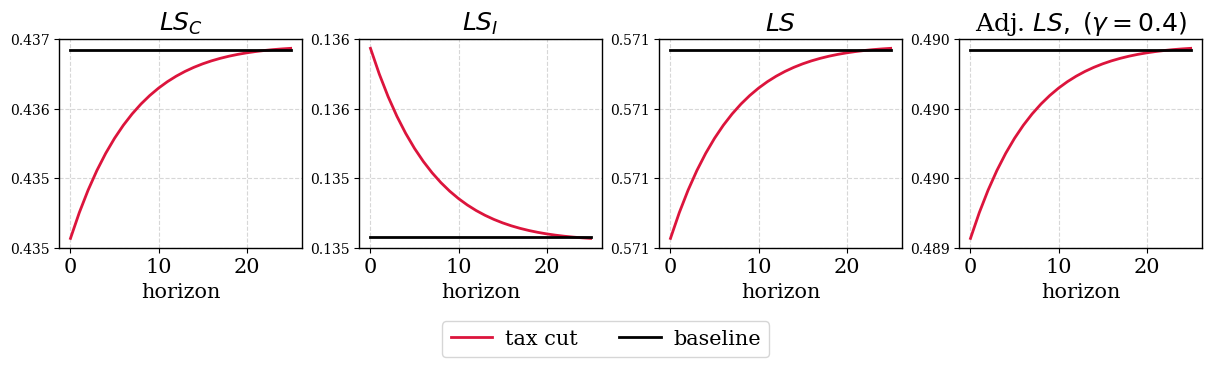

In [7]:
# truncate for plotting
sl = slice(0, T_plot + 1)
ls1 = {k: np.asarray(v)[sl] for k, v in ls1_full.items()}
ls2 = {k: np.asarray(v)[sl] for k, v in ls2_full.items()}
h   = np.arange(T_plot + 1)

panels = list(var_groups.panels(gamma))
n_used = len(panels)

ncols = 4
nrows = math.ceil(n_used / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, 3),
    sharex=True,
    constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()

for i, (k, ttl) in enumerate(panels):
    ax = axes[i]
    ax.plot(h, ls1[k], lw=2, color="crimson", label="tax cut")
    ax.plot(h, ls2[k], lw=2, color="k",       label="baseline")
    ax.set_title(ttl)
    ax.set_xlabel("horizon")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.tick_params(axis="y", labelsize=10)

# hide unused axes
for j in range(n_used, len(axes)):
    axes[j].set_axis_off()

# one legend at bottom (cleanest)
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),  # move up/down as needed
    ncol=len(labels),
    frameon=True
)

plt.show()

*All key variable dynamics*

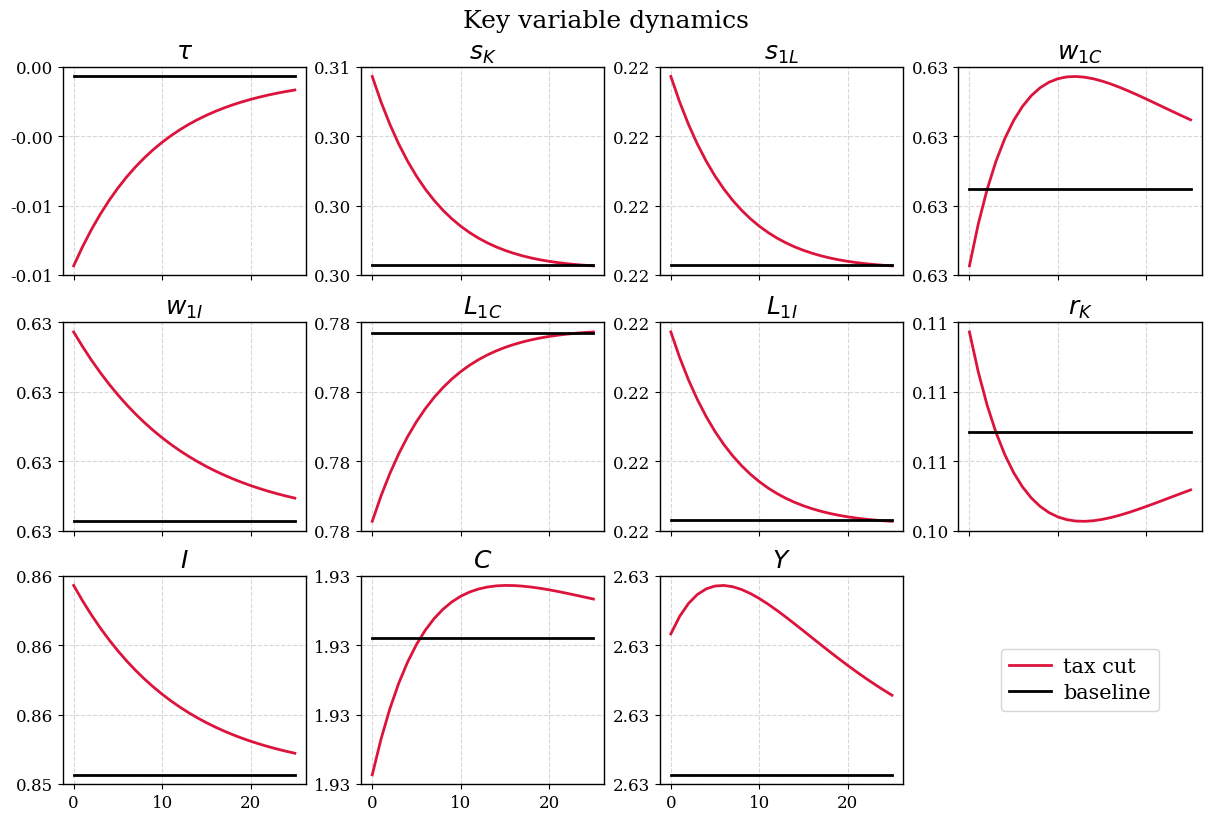

In [17]:
T_plot = 25
sl = slice(0, T_plot + 1)

def trunc_pack(sim, ls):
    S = {**sim, **ls}
    out = {}
    for k, v in S.items():
        a = np.asarray(v)
        out[k] = a[sl] if a.ndim >= 1 and len(a) >= (T_plot + 1) else v
    return out

S1 = trunc_pack(sim1, ls1)
S2 = trunc_pack(sim2, ls2)

# choose/order keys (edit freely)
keys = [
    "tau",
    # 'pI',
    "sK","s1",
    # "s2","w2C","w2I","L2C","L2I",
    "w1C","w1I", 
    "L1C","L1I",
    "rC_gross","I","C","Y"
]
T = min(
    len(np.asarray(S1[keys[0]])), 
    len(np.asarray(S2[keys[0]])), 
)
h = np.arange(T)

ncols = 4
nrows = math.ceil(len(keys) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, 2.7*nrows),
    sharex=True,
    constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()
fig.suptitle('Key variable dynamics')

for i, k in enumerate(keys):
    ax = axes[i]
    ax.plot(h, np.asarray(S1[k])[:T], lw=2, color="crimson")
    ax.plot(h, np.asarray(S2[k])[:T], lw=2, color="k")
    ax.set_title(var_groups.model_var.get(k, k))
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

for ax in axes:
    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis="y", labelsize=12)
    ax.tick_params(axis="x", labelsize=12)
    
    
# hide any unused panels
for j in range(len(keys), len(axes)):
    axes[j].set_axis_off()
 
# one legend for the whole figure
axes[0].plot([], [], lw=2, color="crimson", label="tax cut")
axes[0].plot([], [], lw=2, color="k",  label="baseline")

first_empty = len(keys)

# 2) turn all unused axes off
for j in range(first_empty, len(axes)):
    axes[j].set_axis_off()

# 3) use the first empty one to host the legend
if first_empty < len(axes):
    ax_leg = axes[first_empty]
    ax_leg.set_axis_off()

    # proxy handles (clean + independent of what's plotted)
    h1 = plt.Line2D([0], [0], color="crimson", lw=2)
    h2 = plt.Line2D([0], [0], color="k",  lw=2)

    ax_leg.legend([h1, h2], ["tax cut", "baseline"], loc="center", frameon=True)

plt.show()